
TABULATED RESULTS
            Classifier  Accuracy
0  Decision Tree (ID3)  0.933333
1     SVM (RBF Kernel)  0.966667

Decision Tree Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


SVM Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


REGULARIZATION RESULTS
L1 (Lasso) Accuracy: 0.845
L2 (R

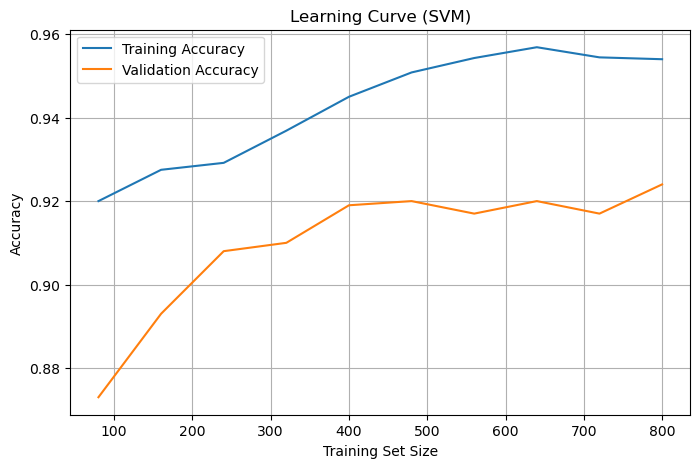

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# PART 1 & 2: IRIS DATASET DECISION TREE (ID3) & SVM
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

svm = SVC(kernel="rbf", gamma="scale")
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# PART 3: TABULATION & COMPARISON
dt_acc = accuracy_score(y_test, dt_pred)
svm_acc = accuracy_score(y_test, svm_pred)

results = pd.DataFrame({
    "Classifier": ["Decision Tree (ID3)", "SVM (RBF Kernel)"],
    "Accuracy": [dt_acc, svm_acc]
})

print("\nTABULATED RESULTS")
print(results)
print("\nDecision Tree Classification Report")
print(classification_report(y_test, dt_pred, target_names=target_names))
print("\nSVM Classification Report")
print(classification_report(y_test, svm_pred, target_names=target_names))

# PART 4: OVERFITTING & GENERALIZATION (SYNTHETIC DATA)
X_syn, y_syn = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=5,
    random_state=42
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

#L1 Regularization (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear')
lasso.fit(X_train_s, y_train_s)

#L2 Regularization (Ridge)
ridge = LogisticRegression(penalty='l2')
ridge.fit(X_train_s, y_train_s)

print("\nREGULARIZATION RESULTS")
print("L1 (Lasso) Accuracy:", lasso.score(X_test_s, y_test_s))
print("L2 (Ridge) Accuracy:", ridge.score(X_test_s, y_test_s))

dt_pruned = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt_pruned.fit(X_train_s, y_train_s)

print("Pruned Decision Tree Accuracy:", dt_pruned.score(X_test_s, y_test_s))
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svm,
    X=X_syn,
    y=y_syn,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (SVM)")
plt.legend()
plt.grid()
plt.show()

